# Cash Flows Through Time
## Payment Terms, Present Value, and Funding Needs

**A 10–15 minute lesson.** Imagine your rent of USD 1,500 is due on the first day of the month, but your paycheck of USD 3,000 arrives on the last day. Your paycheck more than covers the rent overall. Yet if you start the month with no cash, you cannot pay the rent when it is due. You need USD 1,500 available before payday—for example, from savings. For this simple example, set aside all other expenses.

The issue is **when cash is available compared with when it must be paid out**. Receiving enough money over the whole month does not mean you have it on the day you need it.

Notebook 1's compute operator faces the same timing question: customer revenue may exceed rental expense, but supplier payments can fall due before customer cash arrives. We will examine that gap between cash coming in and cash going out.

We will separate service revenue and expense from payments, calculate the largest cash shortfall, and compare monthly supplier payments with an upfront offer. The [SEC's financial-statements guide](https://www.sec.gov/about/reports-publications/investorpubsbegfinstmtguide) explains why income and cash flow differ. Our contribution measure excludes many costs and is not net income.

All payment arrangements, prices, and rates below are **hypothetical teaching assumptions**, not market quotes or standard industry terms. Begin with matched payments; then change their timing to see where funding needs come from.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from liquid_compute import compute_monthly_economics
from liquid_compute.education import show_monthly_results

# Hypothetical operating inputs, carried forward from Notebook 1.
gpu_count = 10
hours_per_month = 720
rental_usd_per_gpu_hour = 2.0
customer_usd_per_gpu_hour = 4.0
utilization_fraction = 0.75

# Hypothetical contract and valuation inputs; starting cash is zero.
service_months = 12
supplier_payment_timing = "monthly_in_arrears"  # Month-end payments
customer_terms = "monthly_in_arrears"
customer_payment_lag_months = 0  # Paid when each service month ends
annual_discount_rate = 0.12  # Effective annual rate, not a borrowing bill
prepayment_discount_fraction = 0.08

operating = compute_monthly_economics(
    gpu_count=gpu_count,
    hours_per_month=hours_per_month,
    rental_usd_per_gpu_hour=rental_usd_per_gpu_hour,
    customer_usd_per_gpu_hour=customer_usd_per_gpu_hour,
    utilization_fraction=utilization_fraction,
)
monthly_revenue_usd = operating.revenue_usd
monthly_rental_expense_usd = operating.rental_expense_usd
show_monthly_results(operating)

| Result | Value | Unit |
|---|---:|---|
| Purchased | 7,200.00 | GPU-hours |
| Billed | 5,400.00 | GPU-hours |
| Unused | 1,800.00 | GPU-hours |
| Revenue | 21,600.00 | USD / modeled month |
| Rental expense | 14,400.00 | USD / modeled month |
| Contribution profit | 7,200.00 | USD / modeled month |
| Margin | 33.33% | % of revenue |
| Break-even utilization | 50.00% | billed / purchased hours |

### Place the payments on a timeline

Service month $m$ runs from $t=m-1$ to $t=m$, measured in whole months from commencement. Initially, both supplier payment and customer receipt occur at $t=m$: boundaries 1 through 12. Nothing moves at time zero.

**Invoice date is not payment date.** An invoice issued at service-end might be paid later. Our lag measures actual receipt after service-end: lag 1 means month 1's cash arrives at $t=2$, regardless of when the invoice was sent.

We net movements at the same boundary and include an opening zero balance. This monthly model excludes intraday settlement needs. A [cash-flow timeline](https://openstax.org/books/principles-finance-2e/pages/9-1-timing-of-cash-flows) makes these dates explicit.

In [3]:
# First three boundaries: t=0, t=1, t=2, under matched month-end terms.
net_cash_flows_usd = [
    0,
    monthly_revenue_usd - monthly_rental_expense_usd,
    monthly_revenue_usd - monthly_rental_expense_usd,
]
balances_usd = []
balance_usd = 0
for net_usd in net_cash_flows_usd:
    balance_usd += net_usd
    balances_usd.append(balance_usd)
early_funding_usd = max(0, -min([0] + balances_usd))
print(f"Cumulative cash at t=0, 1, 2 (USD): {balances_usd}")
print(f"Funding needed so far (USD): {early_funding_usd:,.2f}")

Cumulative cash at t=0, 1, 2 (USD): [0, 7200.0, 14400.0]
Funding needed so far (USD): 0.00


The balances are USD 0, 7,200, and 14,400. Each receipt covers that boundary's rental payment. With positive monthly contribution, matched timing requires no external funding under our netting assumption.

For the full schedule, net cash is receipts minus payments; cumulative cash is the running sum. **Maximum funding** is the negative lowest balance, floored at zero. A negative balance identifies missing cash; it does not assume an overdraft is available.

**All amounts in USD; t = months from commencement.**

| Month t | Service revenue | Service expense | Receipts | Payments | Net cash | Cumulative cash |
|---:|---:|---:|---:|---:|---:|---:|
| 0 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 |
| 1 | 21,600.00 | 14,400.00 | 21,600.00 | 14,400.00 | 7,200.00 | 7,200.00 |
| 2 | 21,600.00 | 14,400.00 | 21,600.00 | 14,400.00 | 7,200.00 | 14,400.00 |
| 3 | 21,600.00 | 14,400.00 | 21,600.00 | 14,400.00 | 7,200.00 | 21,600.00 |
| 4 | 21,600.00 | 14,400.00 | 21,600.00 | 14,400.00 | 7,200.00 | 28,800.00 |
| 5 | 21,600.00 | 14,400.00 | 21,600.00 | 14,400.00 | 7,200.00 | 36,000.00 |
| 6 | 21,600.00 | 14,400.00 | 21,600.00 | 14,400.00 | 7,200.00 | 43,200.00 |
| 7 | 21,600.00 | 14,400.00 | 21,600.00 | 14,400.00 | 7,200.00 | 50,400.00 |
| 8 | 21,600.00 | 14,400.00 | 21,600.00 | 14,400.00 | 7,200.00 | 57,600.00 |
| 9 | 21,600.00 | 14,400.00 | 21,600.00 | 14,400.00 | 7,200.00 | 64,800.00 |
| 10 | 21,600.00 | 14,400.00 | 21,600.00 | 14,400.00 | 7,200.00 | 72,000.00 |
| 11 | 21,600.00 | 14,400.00 | 21,600.00 | 14,400.00 | 7,200.00 | 79,200.00 |
| 12 | 21,600.00 | 14,400.00 | 21,600.00 | 14,400.00 | 7,200.00 | 86,400.00 |

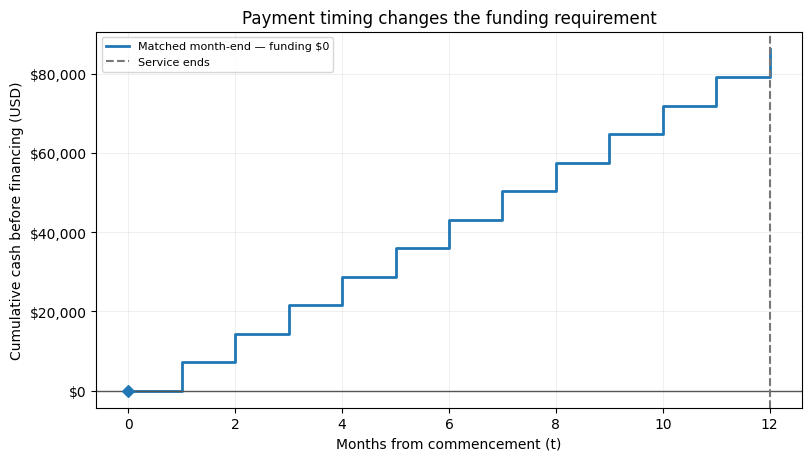

In [4]:
from liquid_compute.cashflows import build_cash_flow_schedule
from liquid_compute.education import plot_cumulative_cash, show_cash_flow_schedule

contract_inputs = dict(
    monthly_revenue_usd=monthly_revenue_usd,
    base_monthly_rental_expense_usd=monthly_rental_expense_usd,
    service_months=service_months,
    customer_payment_lag_months=customer_payment_lag_months,
    customer_terms=customer_terms,
)
monthly = build_cash_flow_schedule(
    **contract_inputs, supplier_terms=supplier_payment_timing
)
show_cash_flow_schedule(monthly)
plot_cumulative_cash({"Matched month-end": monthly}, service_months=service_months);

### Experiment 1 — create a payment gap

We sell the same compute and earn the same contribution in all three scenarios. Change only **when money changes hands**: first pay the supplier earlier, then collect from the customer later.

Service month $m$ starts at $t=m-1$ and ends at $t=m$. The table describes the payments **for that month's service**. The scenario names match the results below.

| Scenario | When do we pay the supplier? | When does the customer pay us? |
|---|---|---|
| **Matched end** | At service-month end: $t=m$ | At the same service-month end: $t=m$ |
| **Supplier at start** | At service-month start: $t=m-1$ | At service-month end: $t=m$ |
| **Plus customer lag** | At service-month start: $t=m-1$ | One month after service-month end: $t=m+1$ |

For **month 1's service**, which runs from $t=0$ to $t=1$:

| Scenario | Supplier payment: USD 14,400 | Customer receipt: USD 21,600 |
|---|---|---|
| Matched end | $t=1$ | $t=1$ |
| Supplier at start | $t=0$ | $t=1$ |
| Plus customer lag | $t=0$ | $t=2$ |

Here, $t=0$ is contract commencement, $t=1$ is one month later, and $t=2$ is two months later. Repeat the same rule for each of the 12 service months. These are cash payment dates, not invoice dates. If you like, predict which arrangement needs the most funding before reading the results.

| Measure (USD) | Matched end | Supplier at start | Plus customer lag |
|---|---:|---:|---:|
| Service revenue | 259,200.00 | 259,200.00 | 259,200.00 |
| Rental expense | 172,800.00 | 172,800.00 | 172,800.00 |
| Contribution profit (undiscounted) | 86,400.00 | 86,400.00 | 86,400.00 |
| Maximum funding (undiscounted) | 0.00 | 14,400.00 | 28,800.00 |

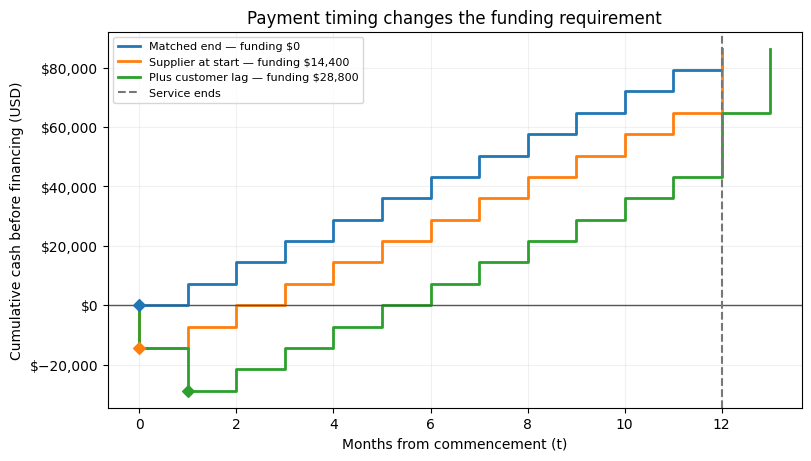

In [5]:
from liquid_compute.education import show_payment_comparison

# Fixed experiments stay comparable even if the top assumptions change.
example = dict(
    monthly_revenue_usd=21600, base_monthly_rental_expense_usd=14400, service_months=12
)
matched = build_cash_flow_schedule(
    **example, supplier_terms="monthly_in_arrears", customer_payment_lag_months=0
)
start_paid = build_cash_flow_schedule(
    **example, supplier_terms="monthly_in_advance", customer_payment_lag_months=0
)
lagged = build_cash_flow_schedule(
    **example, supplier_terms="monthly_in_advance", customer_payment_lag_months=1
)
gaps = {
    "Matched end": matched,
    "Supplier at start": start_paid,
    "Plus customer lag": lagged,
}
show_payment_comparison(gaps, annual_discount_rate=0.12, include_supplier_pv=False)
plot_cumulative_cash(gaps, service_months=12);

**What this shows:** funding rises from USD 0 to 14,400, then 28,800:

- **Matched end:** each month's customer receipt covers that month's supplier payment at the same boundary. There is no cash shortfall under our same-date netting assumption.
- **Supplier at start:** we pay USD 14,400 at $t=0$, before any customer cash arrives. At $t=1$, the first customer receipt and the second month's supplier payment are netted together, so the deficit starts shrinking.
- **Plus customer lag:** we pay USD 14,400 at both $t=0$ and $t=1$ before the first customer receipt arrives at $t=2$. That makes the largest deficit USD 28,800. The final customer receipt arrives at $t=13$.

All three earn USD 86,400 contribution and finish with that same cash balance. Only payment dates changed: earlier outflows and later inflows increase the cash we must provide along the way.

### Experiment 2 — the customer pays first

Suppose the customer prepays the **entire** USD 259,200 contract at commencement, with no customer discount, and that cash clears before the first supplier debit. Supplier rent remains monthly at the start. What happens to the funding gap?

| Measure (USD) | Customer pays with lag | Customer prepays |
|---|---:|---:|
| Service revenue | 259,200.00 | 259,200.00 |
| Rental expense | 172,800.00 | 172,800.00 |
| Contribution profit (undiscounted) | 86,400.00 | 86,400.00 |
| Maximum funding (undiscounted) | 28,800.00 | 0.00 |

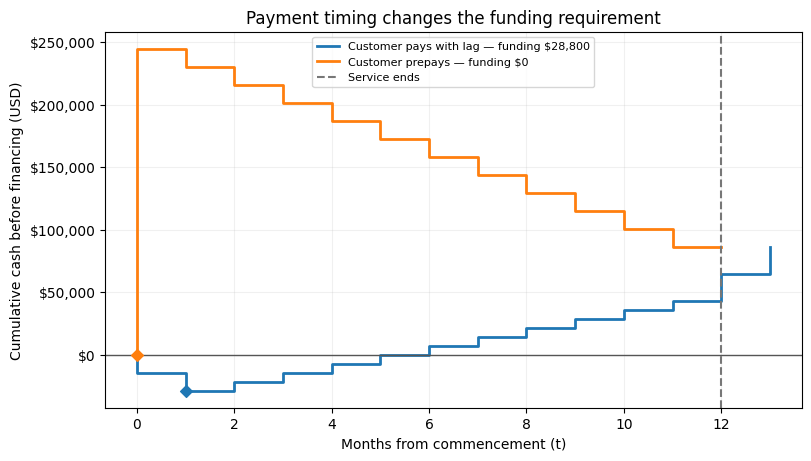

In [6]:
customer_prepaid = build_cash_flow_schedule(
    **example,
    supplier_terms="monthly_in_advance",
    customer_terms="upfront",
    customer_payment_lag_months=0,
)
customer_comparison = {
    "Customer pays with lag": lagged,
    "Customer prepays": customer_prepaid,
}
show_payment_comparison(
    customer_comparison, annual_discount_rate=0.12, include_supplier_pv=False
)
plot_cumulative_cash(customer_comparison, service_months=12);

**What this shows:** customer prepayment removes the modeled funding requirement. After the first supplier payment, USD 244,800 remains to fund later rent. Contribution is still USD 86,400: collecting money early creates liquidity, not additional service revenue.

Revenue is recognized across the 12 service months, even though cash arrives at time zero. This deliberately favorable arrangement assumes customer agreement and receipt before payment; the monthly chart cannot establish intraday settlement order.

### Compare payments in today's dollars

Imagine a friend owes you USD 100. They offer a choice: **take USD 100 today, or receive USD 100 one year from now.** Suppose a one-year bond could turn USD 100 invested today into USD 105 at maturity—a hypothetical 5% return. To isolate timing, assume both payments are certain and ignore taxes and fees.

Taking the money today lets you buy the bond and finish the year with USD 105. Waiting for your friend leaves you with only USD 100. The USD 5 you give up by waiting is an **opportunity cost**: the benefit of the alternative you did not choose. Under these assumptions, taking USD 100 today is financially better.

This is the **time value of money**: the same dollar amount at different dates can have different value because money available now can earn a return. Your friend would need to offer USD 105 in a year to match USD 100 today at that 5% rate.

Now reverse the question: **how much money today would grow to the promised USD 100 in one year?** Divide by 1.05: USD 100 / 1.05 = approximately **USD 95.24**. That is the *present value* of USD 100 received in a year at 5%. [OpenStax explains discounting as the reverse of growth](https://openstax.org/books/principles-finance-2e/pages/7-4-applications-of-tvm-in-finance).

Our operator uses the same arithmetic for money paid out. Paying a supplier later lets the operator keep its cash longer. Present value expresses each future bill as an equivalent amount today so we can compare payment dates.

**Where does the discount rate come from?** It reflects the financial alternative used for the comparison. For a savings decision, you might use the return available on a comparable investment: what you give up by spending the money now. Businesses may use their cost of obtaining funds, called the **cost of capital**. The choice should fit the cash flow's timing and risk; there is no single rate for every decision. [OpenStax discusses the business choice of rate](https://openstax.org/books/principles-finance/pages/16-2-net-present-value-npv-method).

Here, **12% is an illustrative assumption**, not an available savings offer, a market quote, or an estimated financing cost for this operator. We use it to compare payment dates. We do not add investment earnings or borrowing interest to the cash schedule. It is also different from the supplier's 8% price discount: one translates money across time; the other changes the bill.

For a payment $A$ due in $t$ months, with effective annual rate $r$:

$$PV = \frac{A}{(1+r)^{t/12}} = A \times DF(t), \qquad DF(t)=(1+r)^{-t/12}.$$

Here $t/12$ converts months to years. The **discount factor** is the multiplier that converts the future payment to its value today. At $t=0$, it is 1. Effective annual means that 12% describes growth over a full year; for one month, use $(1+r)^{1/12}$, not $1+r/12$.

The code works through the friend example at 5%, then returns to the operator’s illustrative 12% rate to value rental payments.

Take USD 100 today and invest: USD 105.00 in one year.
Wait for the friend: USD 100.00 in one year.
Return forgone by waiting: USD 5.00.
Value today of the friend's future payment: USD 95.24.
Month-1 payment: USD 14,400.00 × 0.990600 = USD 14,264.65 today.
All monthly supplier payments, valued today: USD 162,597.83


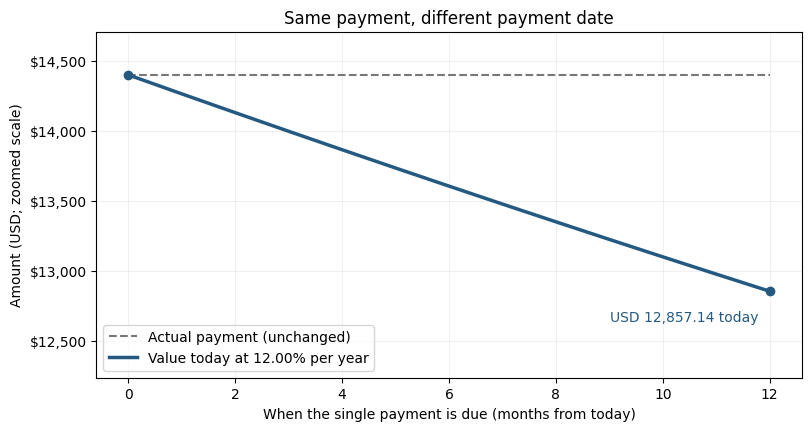

In [7]:
from liquid_compute.education import plot_payment_present_value

# Friend example: a hypothetical 5% alternative return over one year.
friend_payment_usd = 100
bond_annual_return = 0.05
bond_maturity_usd = friend_payment_usd * (1 + bond_annual_return)
friend_payment_pv_usd = friend_payment_usd / (1 + bond_annual_return)
print(f"Take USD 100 today and invest: USD {bond_maturity_usd:.2f} in one year.")
print(f"Wait for the friend: USD {friend_payment_usd:.2f} in one year.")
print(f"Return forgone by waiting: USD {bond_maturity_usd - friend_payment_usd:.2f}.")
print(f"Value today of the friend's future payment: USD {friend_payment_pv_usd:.2f}.")

# Return to the operator's rate from the editable assumptions (default 12%).
# Backward: today's equivalent of one rental payment due in one month.
month_one_factor = (1 + annual_discount_rate) ** (-1 / 12)
month_one_pv_usd = monthly_rental_expense_usd * month_one_factor
print(
    f"Month-1 payment: USD {monthly_rental_expense_usd:,.2f} × {month_one_factor:.6f} = USD {month_one_pv_usd:,.2f} today."
)

# Each monthly bill has its own date: value each one, then add.
payment_months = (
    range(1, service_months + 1)
    if supplier_payment_timing == "monthly_in_arrears"
    else range(service_months)
)
monthly_supplier_pv_usd = sum(
    monthly_rental_expense_usd * (1 + annual_discount_rate) ** (-t / 12)
    for t in payment_months
)
print(
    f"All monthly supplier payments, valued today: USD {monthly_supplier_pv_usd:,.2f}"
)

plot_payment_present_value(
    payment_usd=monthly_rental_expense_usd,
    annual_discount_rate=annual_discount_rate,
    horizon_months=12,
);

**Reading the plot:** each point considers the same single USD 14,400 bill paid at a different date; this is not cumulative cash or a series of additional bills. The dashed line stays at USD 14,400 because the amount owed does not change. At 12%, its value today falls from USD 14,400 if due now to USD 12,857.14 if due in a year. A later payment has a lower present cost because we can keep the money longer. With a zero rate, the two lines would coincide.

Present value is a comparison, not permission to pay less: if the bill says USD 14,400 next month, that full amount is still due.

### A new offer: we prepay our supplier

**We now switch from the customer prepaying us to us prepaying the supplier.** Return to the baseline: our customer pays us USD 21,600 at each month-end. The customer receives no discount and does not pay the full contract upfront in this comparison.

Our supplier offers a choice: keep paying USD 14,400 each month-end, or pay for all 12 months of GPU rental at commencement and receive an **8% reduction in the total rental price**. The operator gets the discount because it pays the supplier early. Delivery remains spread over the same 12 months.

| Arrangement | We pay the supplier | The customer pays us |
|---|---|---|
| Supplier monthly | USD 14,400 each month-end | USD 21,600 each month-end |
| Supplier upfront, no discount | USD 172,800 at $t=0$ | USD 21,600 each month-end |
| Supplier upfront, 8% discount | USD 158,976 at $t=0$ | USD 21,600 each month-end |

These amounts use the original example inputs. The no-discount case helps separate the effect of paying earlier from the effect of receiving a lower price.

**First, calculate the price and profit.** With base monthly rent $C$, duration $T$, and supplier discount $d$, the upfront bill is $U=TC(1-d)$. The rental saving is $TC-U$. We allocate that bill across the months of service: expense is $U/T$ per month, even though the cash leaves at commencement. Total contribution is $TR-U$, where $R$ is monthly customer revenue.

Money has time value, and paying upfront means giving up the opportunity to use that cash while we would otherwise be paying monthly. The question becomes: **“How large an upfront price discount would compensate me for giving up that cash now? At what discount would prepaying be financially equivalent to paying monthly—and when would prepaying become the better deal?”**

We use the chosen annual discount rate to value that opportunity cost, then solve for the supplier’s required price discount. These are two different rates: the annual rate values the timing of money; the supplier discount reduces the bill.

**What is the break-even supplier discount?** It is the price reduction that makes paying all supplier rent upfront financially equivalent to paying monthly, using our chosen annual discount rate. It compensates us for giving up cash earlier.

For the original example at the assumed 12% annual discount rate:

| Step | Amount |
|---|---:|
| Add the 12 monthly supplier bills: $TC$ | USD 172,800.00 |
| Value those monthly bills at commencement: $PV_{\mathrm{monthly}}$ | USD 162,597.83 |
| Reduce the total bill to that equivalent upfront price | USD 10,202.17 |
| Express that reduction as a fraction of the total bill | $1 - 162{,}597.83 / 172{,}800 = 5.904\%$ |

In general, the **break-even supplier discount** is:

$$d^* = 1 - \frac{PV_{\mathrm{monthly}}}{TC}.$$

- **Above 5.904%:** supplier prepayment has the lower present cost.
- **At 5.904%:** the two payment choices have approximately equal present cost.
- **Below 5.904%:** monthly supplier payments have the lower present cost.

This is **break-even between payment choices, not break-even business profit**. The threshold depends on the payment dates and chosen valuation rate. Even an offer above the threshold still requires enough cash to pay the entire upfront bill. We assume identical delivery and customer receipts and exclude supplier delivery and credit risk.

In [8]:
# What do we pay the supplier, and how does the lower price change profit?
undiscounted_rent_usd = service_months * monthly_rental_expense_usd
upfront_price_usd = undiscounted_rent_usd * (1 - prepayment_discount_fraction)
rental_saving_usd = undiscounted_rent_usd - upfront_price_usd
allocated_monthly_expense_usd = upfront_price_usd / service_months
upfront_contribution_usd = service_months * monthly_revenue_usd - upfront_price_usd

# What supplier discount makes paying upfront equivalent in present cost?
break_even_discount = 1 - monthly_supplier_pv_usd / undiscounted_rent_usd
print(f"We pay the supplier at commencement: USD {upfront_price_usd:,.2f}")
print(f"Total rental saving from the supplier's discount: USD {rental_saving_usd:,.2f}")
print(
    f"Rental expense allocated to each service month: USD {allocated_monthly_expense_usd:,.2f}"
)
print(
    f"Our total contribution after the supplier discount: USD {upfront_contribution_usd:,.2f}"
)
print(f"Supplier discount needed for equal present cost: {break_even_discount:.4%}")

We pay the supplier at commencement: USD 158,976.00
Total rental saving from the supplier's discount: USD 13,824.00
Rental expense allocated to each service month: USD 13,248.00
Our total contribution after the supplier discount: USD 100,224.00
Supplier discount needed for equal present cost: 5.9040%


**What the offer changes:** the supplier's 8% discount saves us USD 13,824 in total rental expense. Customer revenue stays USD 259,200, so our contribution increases from USD 86,400 to USD 100,224. The customer has not paid us early; we still have to find the upfront cash ourselves.

### Is that saving worth the earlier cash payment?

The next cell compares the three supplier arrangements in the table above. Read its results as three separate questions:

- **Profit:** how much customer revenue remains after rental expense? Paying the supplier early without a discount leaves contribution unchanged. The 8% price reduction increases it.
- **Funding:** how much cash must we provide before customer receipts cover our payments? Monthly matched payments need zero funding. Supplier prepayment needs USD 172,800 without a discount, or USD 158,976 with the 8% discount.
- **Present cost:** does the price saving compensate for paying the supplier sooner? At the illustrative 12% rate, monthly supplier payments have PV USD 162,597.83. The discounted upfront bill is USD 158,976, a PV saving of USD 3,621.83. Its 8% discount exceeds the 5.9040% break-even discount.

The offer improves profit and has a lower present cost under these assumptions, but it also requires substantial cash immediately. A favorable valuation does not tell us whether we can fund the purchase. The chart below shows that cash requirement; it is not a present-value chart.

| Measure (USD) | Supplier monthly | Supplier upfront: no discount | Supplier upfront: offered discount |
|---|---:|---:|---:|
| Service revenue | 259,200.00 | 259,200.00 | 259,200.00 |
| Rental expense | 172,800.00 | 172,800.00 | 158,976.00 |
| Contribution profit (undiscounted) | 86,400.00 | 86,400.00 | 100,224.00 |
| Maximum funding (undiscounted) | 0.00 | 172,800.00 | 158,976.00 |
| PV of supplier payments | 162,597.83 | 172,800.00 | 158,976.00 |

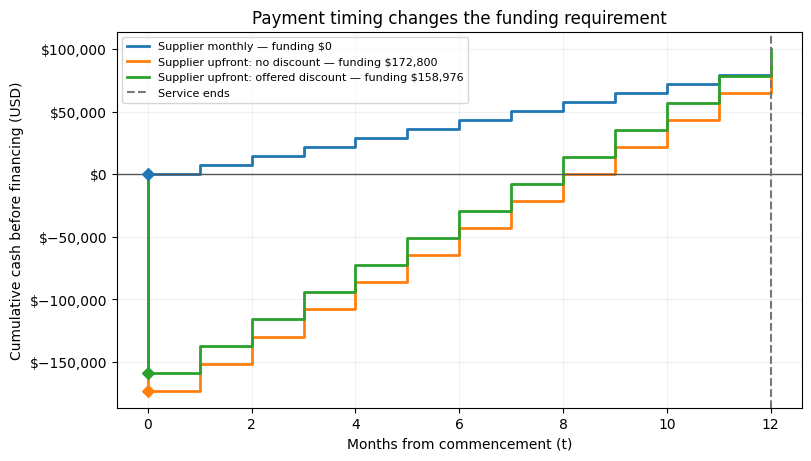

In [9]:
upfront = build_cash_flow_schedule(
    **contract_inputs,
    supplier_terms="upfront",
    prepayment_discount_fraction=prepayment_discount_fraction,
)
no_discount = build_cash_flow_schedule(**contract_inputs, supplier_terms="upfront")
supplier_comparison = {
    "Supplier monthly": monthly,
    "Supplier upfront: no discount": no_discount,
    "Supplier upfront: offered discount": upfront,
}
show_payment_comparison(supplier_comparison, annual_discount_rate=annual_discount_rate)
plot_cumulative_cash(supplier_comparison, service_months=service_months);

### Explore the agreements

Change supplier timing, customer terms, customer lag, the annual valuation rate, or the supplier’s price discount. The table compares regular supplier payments with supplier prepayment, holding customer terms constant. Here, the discount control always reduces the supplier’s bill; it never reduces customer revenue. Choosing customer upfront separately means the customer pays us the full contract price at commencement and requires lag zero. Rates are fractions; 0.12 means 12%.

These controls leave the fixed experiments unchanged. If widgets are unavailable, edit the top assumptions and rerun the calculation cells. Delivery length and operating inputs stay in those cells.

In [10]:
from liquid_compute.education import explore_payment_terms

explore_payment_terms(
    **contract_inputs,
    supplier_payment_timing=supplier_payment_timing,
    annual_discount_rate=annual_discount_rate,
    prepayment_discount_fraction=prepayment_discount_fraction,
);

### Experiment 3 — change the valuation rate

Keep the customer paying monthly at month-end. Compare month-end supplier payments with us prepaying the supplier for an 8% discount, using the fixed example inputs. Raise only the annual discount rate from 12% to 24%. Does the offer still have the lower present cost?

In [11]:
from liquid_compute.discounting import break_even_prepayment_discount_fraction

fixed_upfront = build_cash_flow_schedule(
    **example,
    customer_payment_lag_months=0,
    supplier_terms="upfront",
    prepayment_discount_fraction=0.08,
)
for rate in [0.12, 0.24]:
    print(f"Effective annual discount rate: {rate:.0%}")
    show_payment_comparison(
        {"Supplier monthly": matched, "Supplier upfront: 8%": fixed_upfront},
        annual_discount_rate=rate,
    )
    threshold = break_even_prepayment_discount_fraction(
        service_months=12,
        annual_discount_rate=rate,
        payment_timing="monthly_in_arrears",
    )
    print(f"Break-even prepayment discount: {threshold:.4%}")

Effective annual discount rate: 12%


| Measure (USD) | Supplier monthly | Supplier upfront: 8% |
|---|---:|---:|
| Service revenue | 259,200.00 | 259,200.00 |
| Rental expense | 172,800.00 | 158,976.00 |
| Contribution profit (undiscounted) | 86,400.00 | 100,224.00 |
| Maximum funding (undiscounted) | 0.00 | 158,976.00 |
| PV of supplier payments | 162,597.83 | 158,976.00 |

Break-even prepayment discount: 5.9040%
Effective annual discount rate: 24%


| Measure (USD) | Supplier monthly | Supplier upfront: 8% |
|---|---:|---:|
| Service revenue | 259,200.00 | 259,200.00 |
| Rental expense | 172,800.00 | 158,976.00 |
| Contribution profit (undiscounted) | 86,400.00 | 100,224.00 |
| Maximum funding (undiscounted) | 0.00 | 158,976.00 |
| PV of supplier payments | 154,088.96 | 158,976.00 |

Break-even prepayment discount: 10.8281%


**What this shows:** at 24%, month-end supplier-payment PV falls to USD 154,088.96 and the required discount rises to 10.8281%. The 8% offer now costs more in present-value terms. Its time-zero price stays USD 158,976.

No contractual payment changed. Contribution and funding remain unchanged in both arrangements. A valuation preference does not supply the cash needed to accept an offer.

### Takeaways and limits

Payment dates can create or remove a funding gap without changing contribution. Customer prepayment can fund purchases; supplier prepayment can reduce price while increasing cash needs. Evaluate profit, funding, and present value separately.

This model assumes certain delivery and collection, constant monthly operations, zero starting cash, and same-boundary netting. It excludes borrowing interest, taxes, defaults, collateral, derivatives, ancillary expenses, and returns on accumulated cash. Expense allocation is a teaching assumption, not accounting-compliance guidance.

**References:** [OpenStax: choosing a business discount rate](https://openstax.org/books/principles-finance/pages/16-2-net-present-value-npv-method); [SEC: financial statements](https://www.sec.gov/about/reports-publications/investorpubsbegfinstmtguide); [OpenStax: time value of money](https://openstax.org/books/principles-finance-2e/pages/7-4-applications-of-tvm-in-finance); [OpenStax: cash-flow timing](https://openstax.org/books/principles-finance-2e/pages/9-1-timing-of-cash-flows). These support the concepts; example terms and results are hypothetical assumptions and derived calculations.

We can now compare payment schedules. What can different contract lengths tell us about the implied price of future delivery periods?